# 03 — Visualization Pack (Deliverable C)

Generates the 12 required PNGs into `figures/` plus `figure_captions.md`.

```bash
python src/visualizations.py
```

Figures 10–12 train a quick chronological model snapshot (HistGBM vs baselines). Full modeling write-up is Deliverable D.

In [1]:
from pathlib import Path
import sys
from IPython.display import Image, display, Markdown

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.visualizations import main
main()

Loading data...


Building fig01–fig09...


Wrote C:\xampp\htdocs\ride_forcasting\figures\fig01_gaps_and_missingness.png


Wrote C:\xampp\htdocs\ride_forcasting\figures\fig02_before_after_cleaning.png


Wrote C:\xampp\htdocs\ride_forcasting\figures\fig03_demand_trend_with_holidays.png


...

Wrote C:\xampp\htdocs\ride_forcasting\figures\fig09_holiday_effects.png
Training quick models for fig10–fig12...


            model       rmse        mae    train_s
0   mean_baseline  27.878944  20.809506   0.000000
1  seasonal_naive  12.078873   7.438533   0.000000
2           ridge  19.592150  13.336310   0.388483
3   random_forest  10.933406   6.749322  26.875634
4        hist_gbm  10.664282   6.686266  18.985929


Wrote C:\xampp\htdocs\ride_forcasting\figures\fig10_model_comparison.png


Wrote C:\xampp\htdocs\ride_forcasting\figures\fig11_forecast_vs_actual.png


Wrote C:\xampp\htdocs\ride_forcasting\figures\fig12_feature_importance.png
Wrote C:\xampp\htdocs\ride_forcasting\figures\figure_captions.md
Done. All 12 figures in figures/


# Figure captions (Deliverable C)

## fig01_gaps_and_missingness.png
Missingness by raw column and weekly missing-hour heatmap by zone. Takeaway: Ayat’s shorter history (late launch) and scattered gaps are visible; cleaning must not invent pre-launch demand.

## fig02_before_after_cleaning.png
Trips and rain distributions before vs after cleaning. Takeaway: capping extreme trip spikes and removing rain sentinels (-9999) removes distortion without hiding the real rainy-hour mass at 0.

## fig03_demand_trend_with_holidays.png
Daily city-wide trips Jan–Oct with 7-day trend and holidays marked. Takeaway: demand rises through the year; holidays often dip below the local trend — November models need a trend term, not only seasonality.

## fig04_hour_by_weekday_heatmap.png
Mean trips by hour×weekday for the city and Merkato. Takeaway: weekday commute peaks differ from weekend shapes — zone-specific seasonality matters.

## fig05_zone_profiles.png
Small-multiples of weekday/weekend hourly profiles by zone type. Takeaway: residential vs hub vs market types peak at different hours — one city-wide curve is not enough.

## fig06_weather_timezone_check.png
Temperature curve on wrong vs corrected clock, and rain–demand correlation for shifts 0–5h. Takeaway: correct EAT alignment peaks temperature in mid-afternoon and strengthens the rain signal — do not join UTC as local.

## fig07_rain_effect.png
Demand ratio versus rain class, one series per zone type. Takeaway: rain lifts demand unevenly by zone type and often saturates from moderate to heavy.

## fig08_event_study.png
Average demand around football match start (−6h to +6h) and concert uplift by hour vs matched non-event baseline. Takeaway: football demand rises before kickoff and stays elevated after; concerts show evening uplift — window features are justified.

## fig09_holiday_effects.png
Index of daily trips for each public holiday relative to nearby same-weekday normals, sorted. Takeaway: most holidays suppress city demand (index<1), but magnitudes differ — keep holiday flags, not a single ‘holiday’ effect size.

## fig10_model_comparison.png
Validation RMSE for baselines and model families; rolling-origin error bar on HistGBM. Takeaway: seasonal naive beats a global mean; boosted trees improve further — report chronological scores only.

## fig11_forecast_vs_actual.png
Predicted vs actual hourly trips for three zones over the validation fortnight. Takeaway: the model tracks daily peaks; largest misses often align with unusual event/weather hours.

## fig12_feature_importance.png
Top features by permutation importance with weather and event features highlighted. Takeaway: lags/calendar dominate, but weather and event features contribute measurable RMSE reduction — Rule 5 is satisfied with signal, not decoration.


fig01_gaps_and_missingness.png


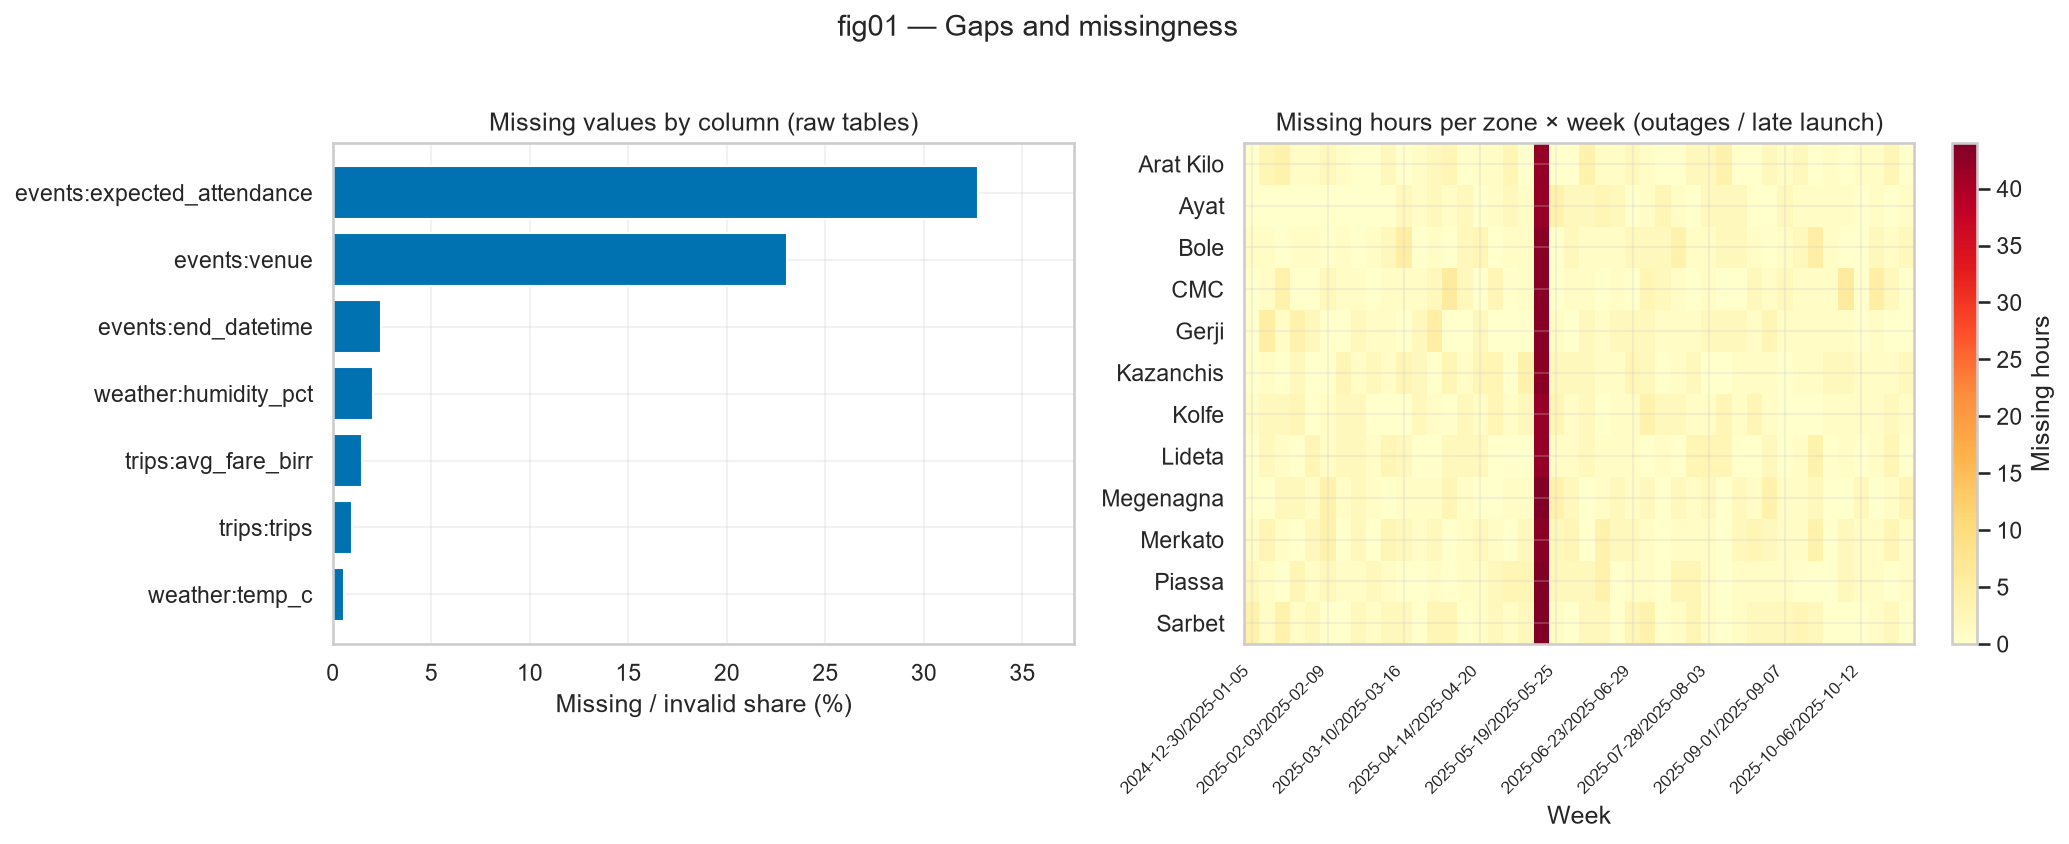

fig02_before_after_cleaning.png


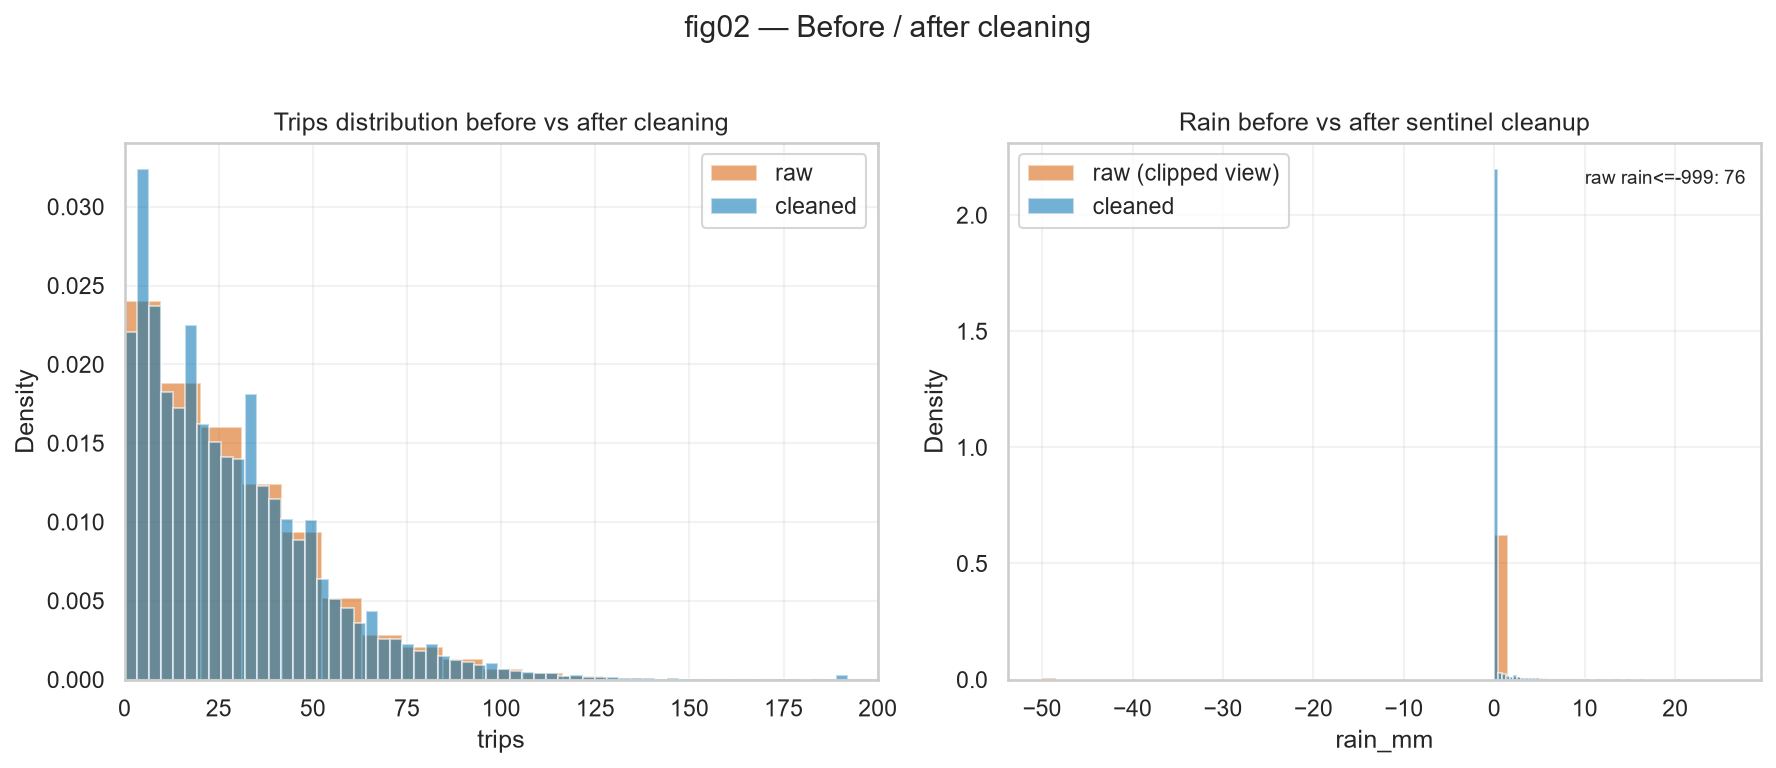

fig03_demand_trend_with_holidays.png


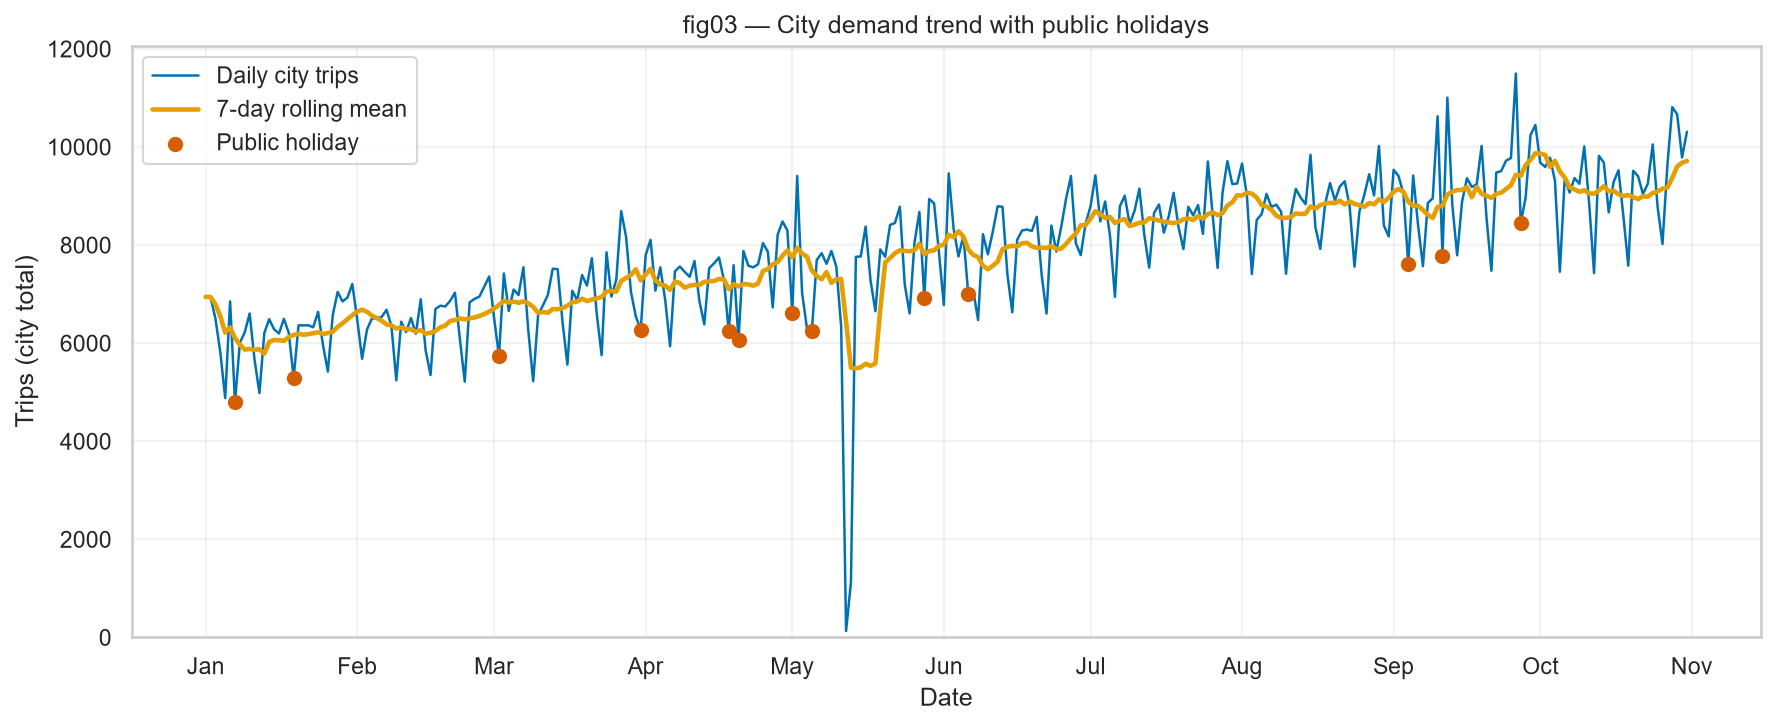

fig04_hour_by_weekday_heatmap.png


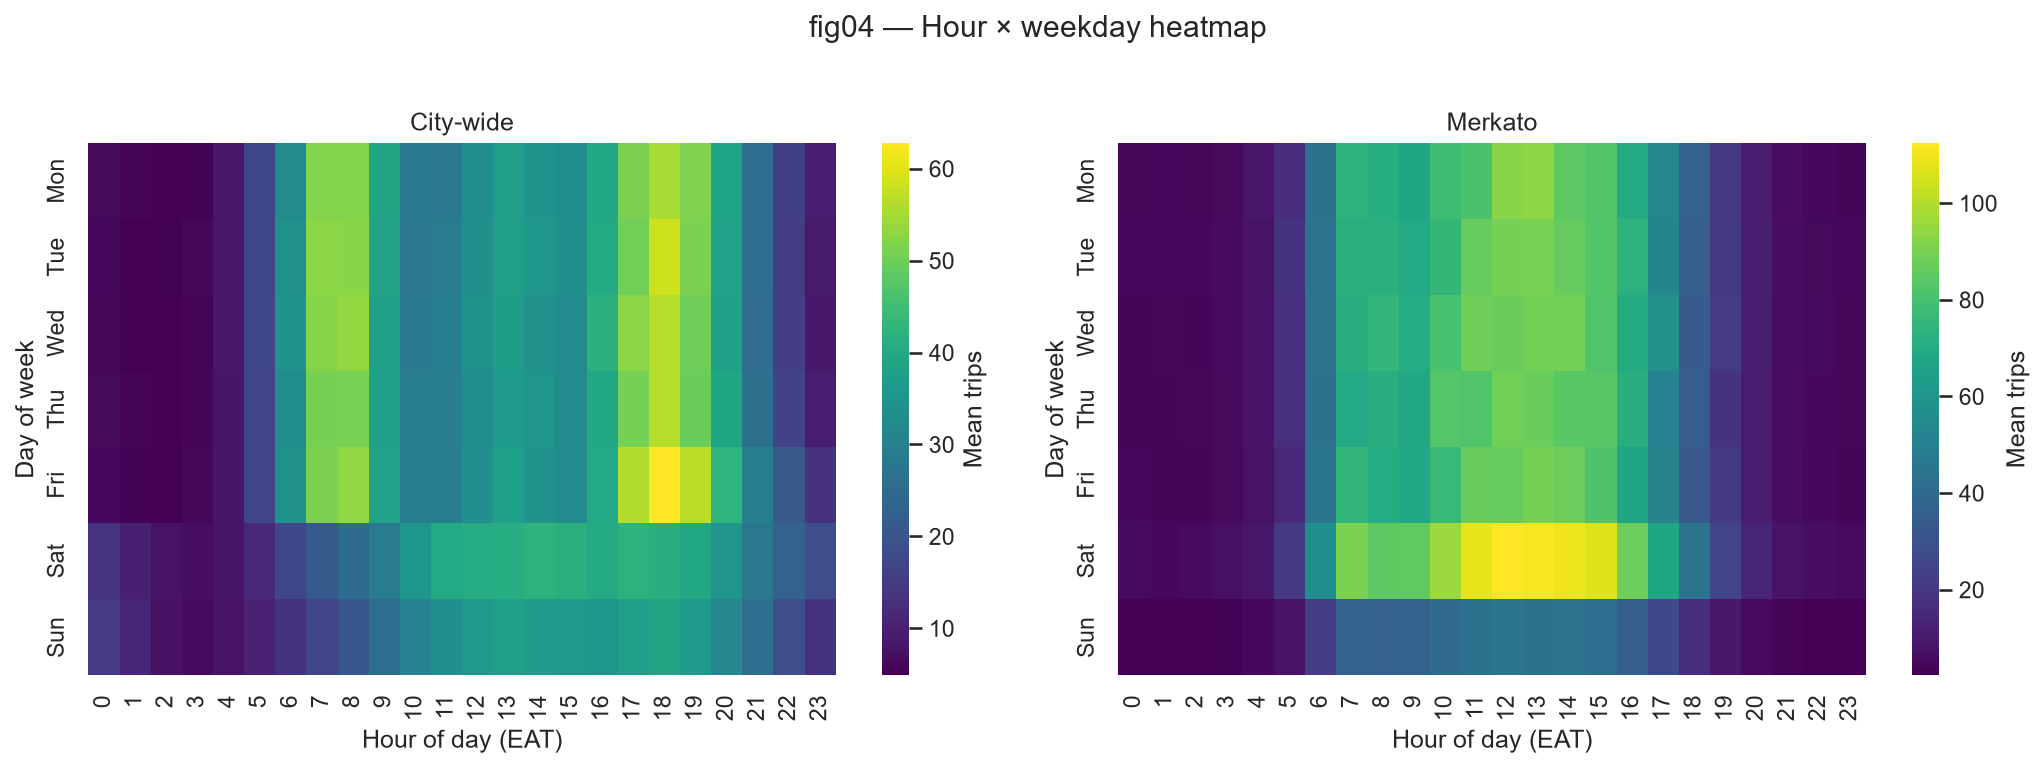

fig05_zone_profiles.png


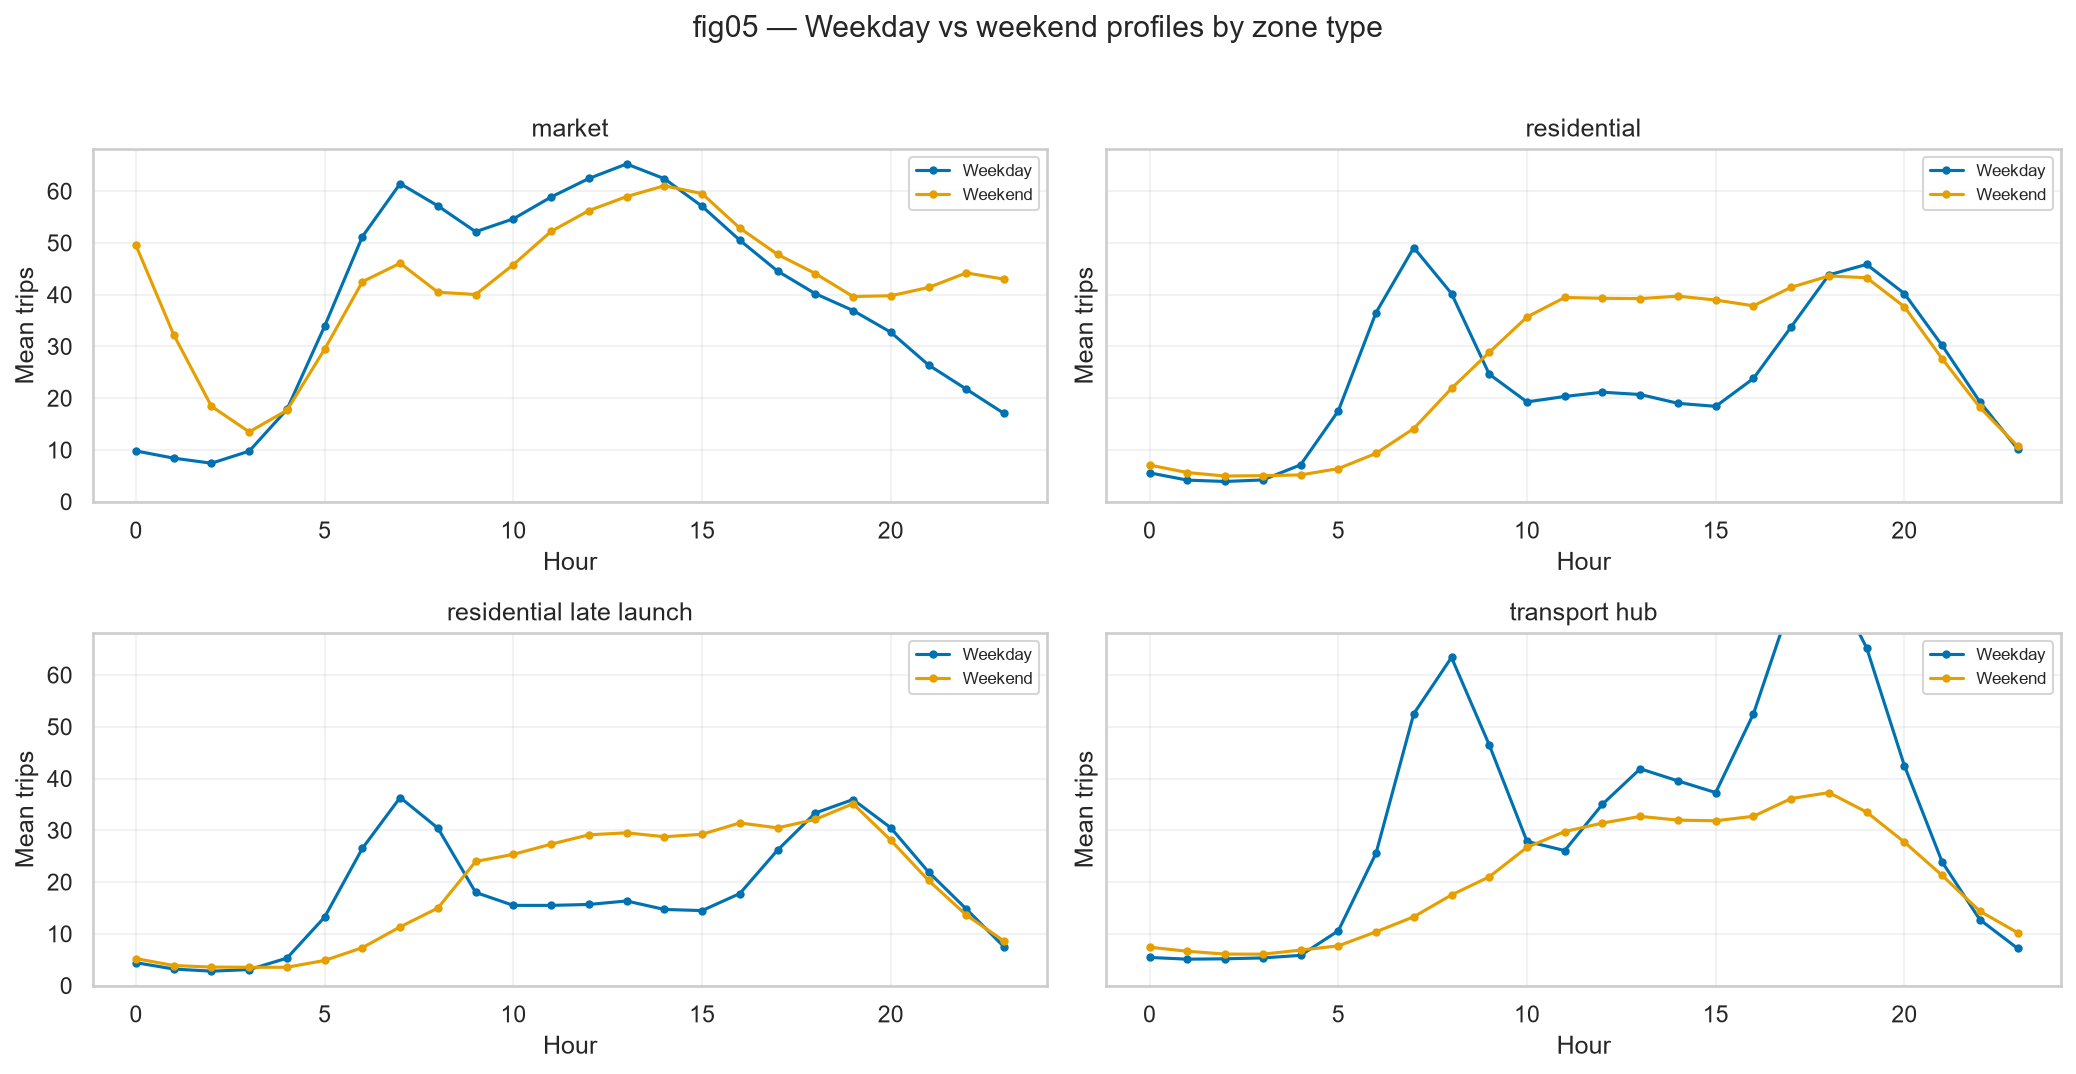

fig06_weather_timezone_check.png


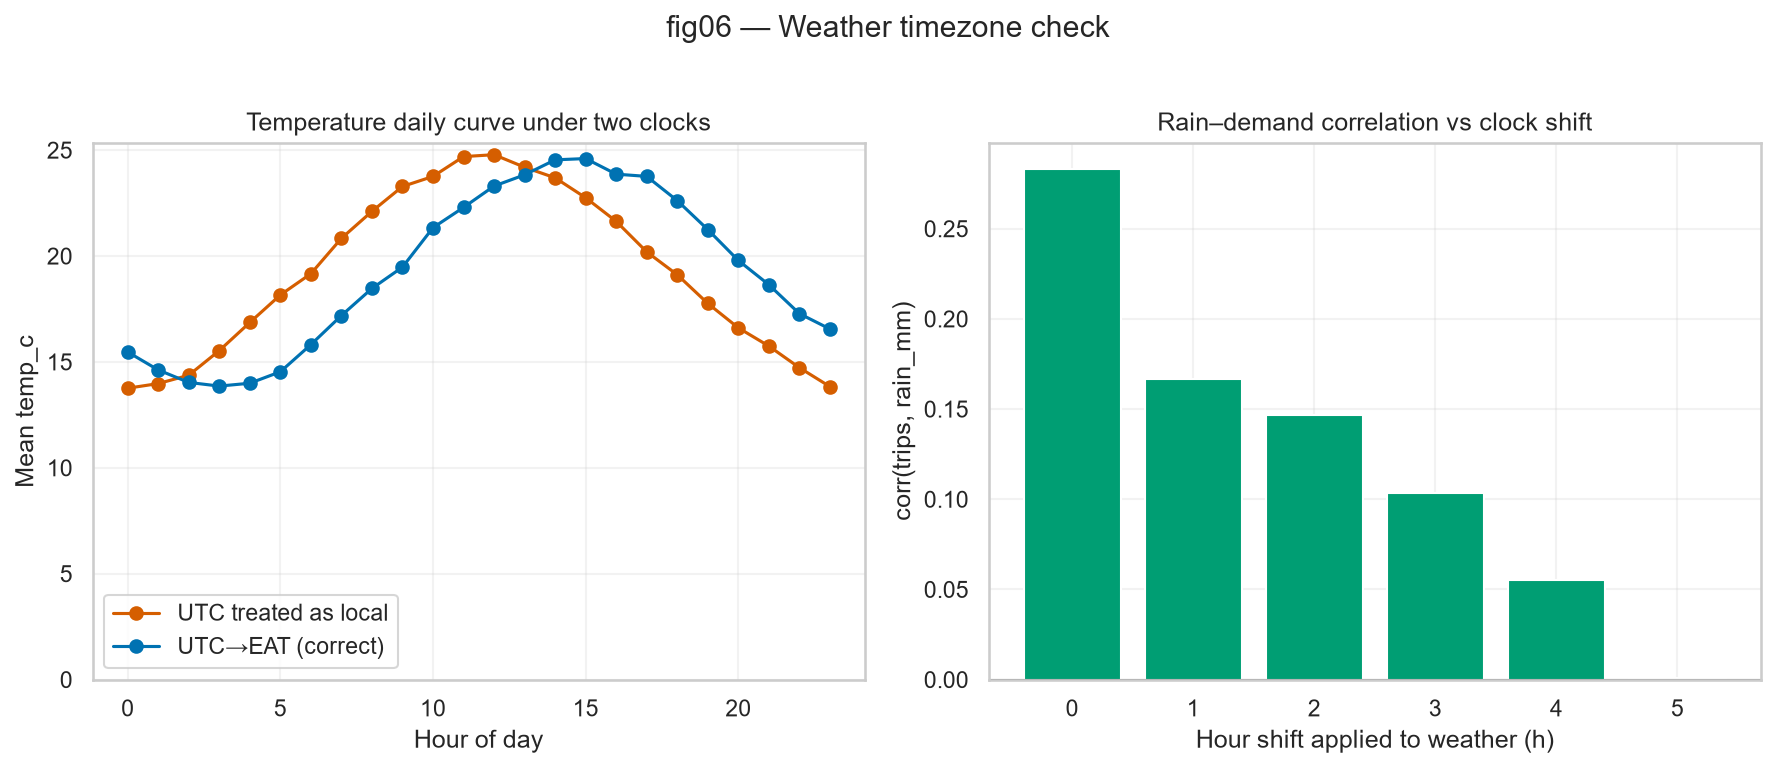

fig07_rain_effect.png


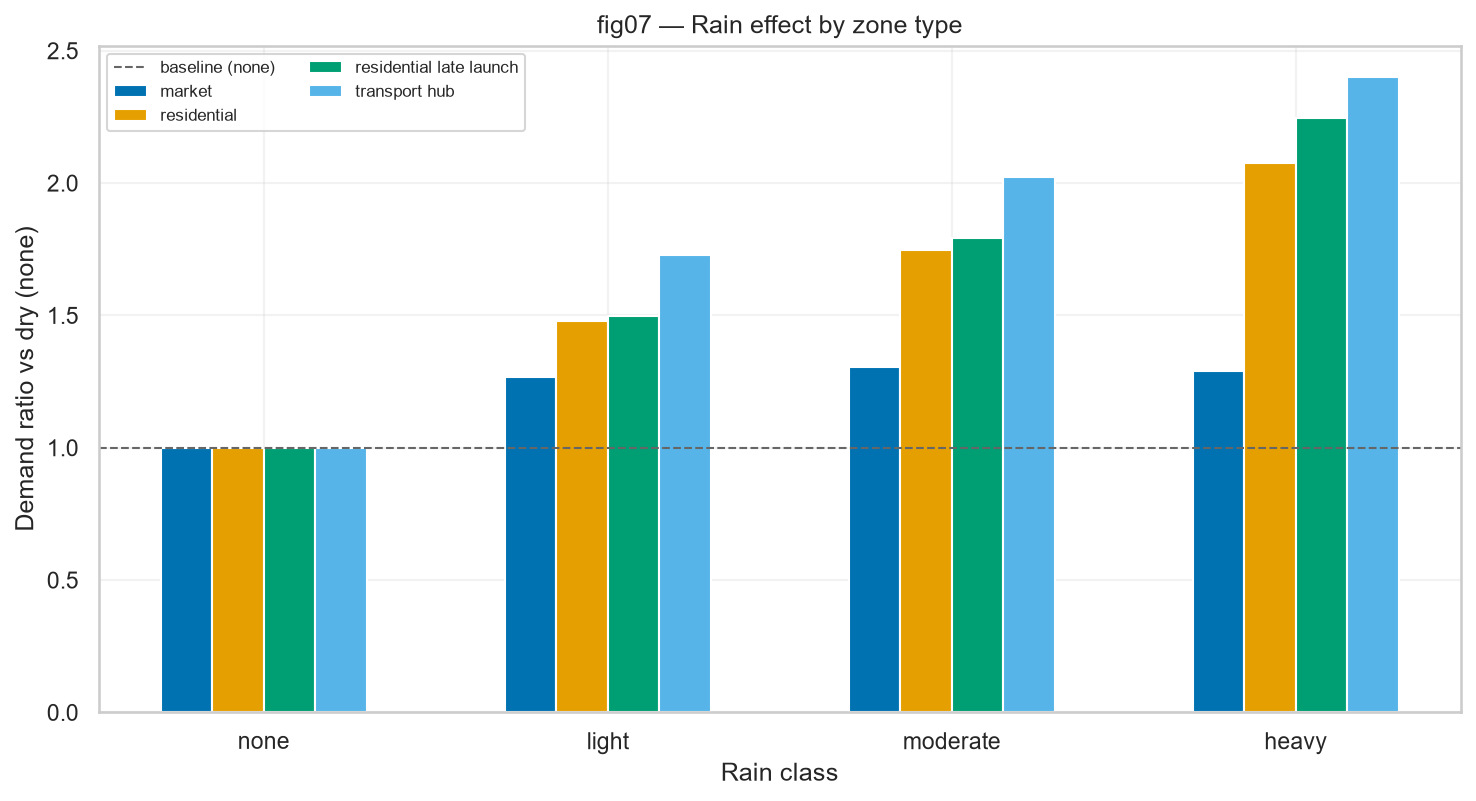

fig08_event_study.png


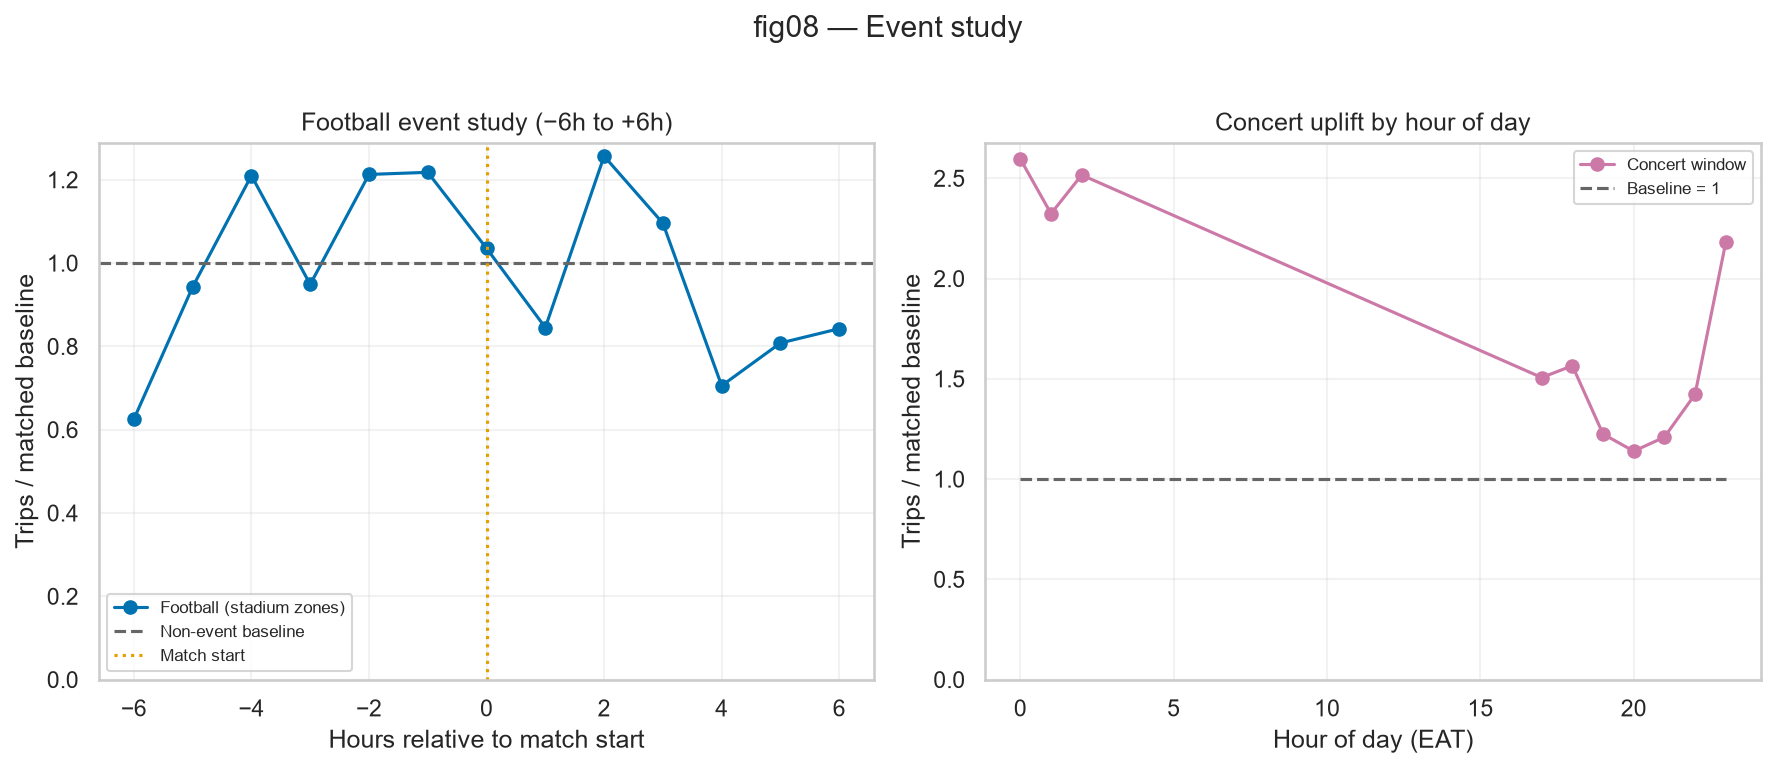

fig09_holiday_effects.png


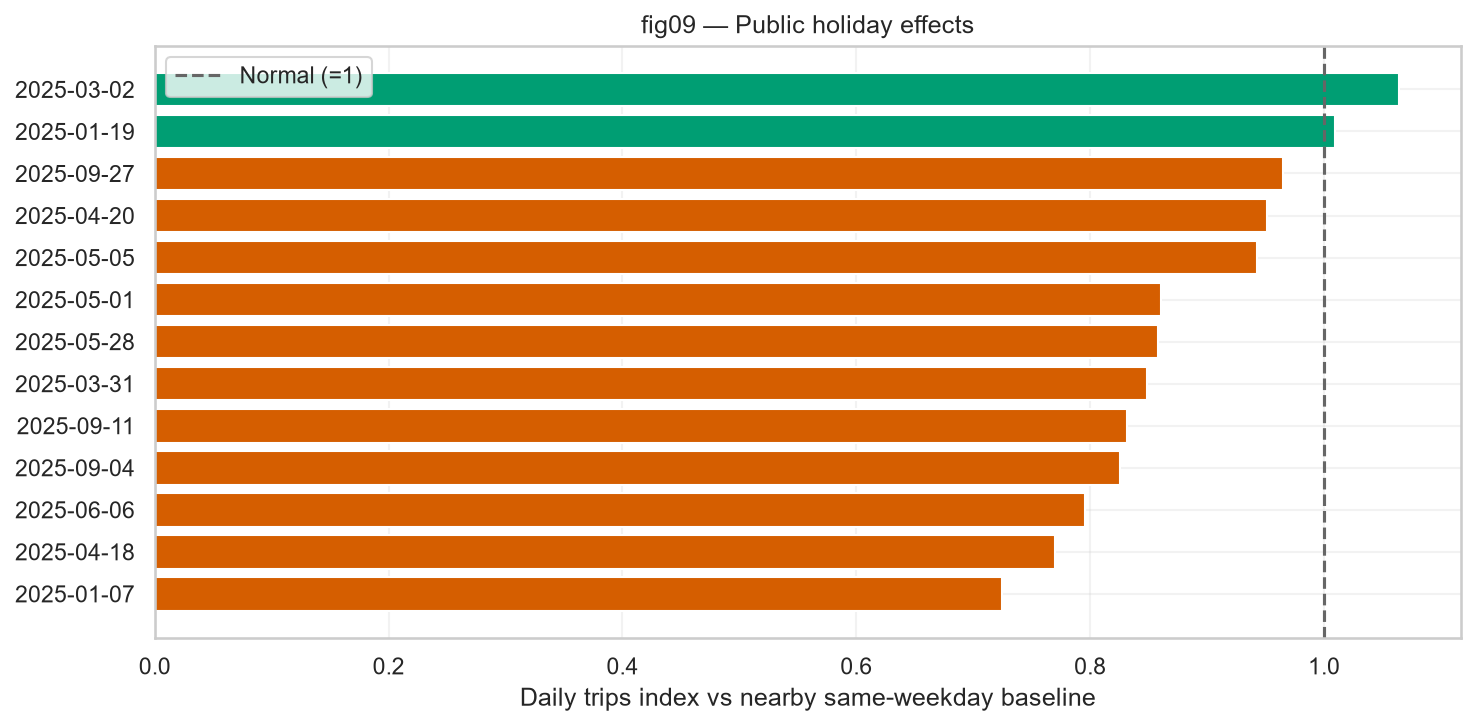

fig10_model_comparison.png


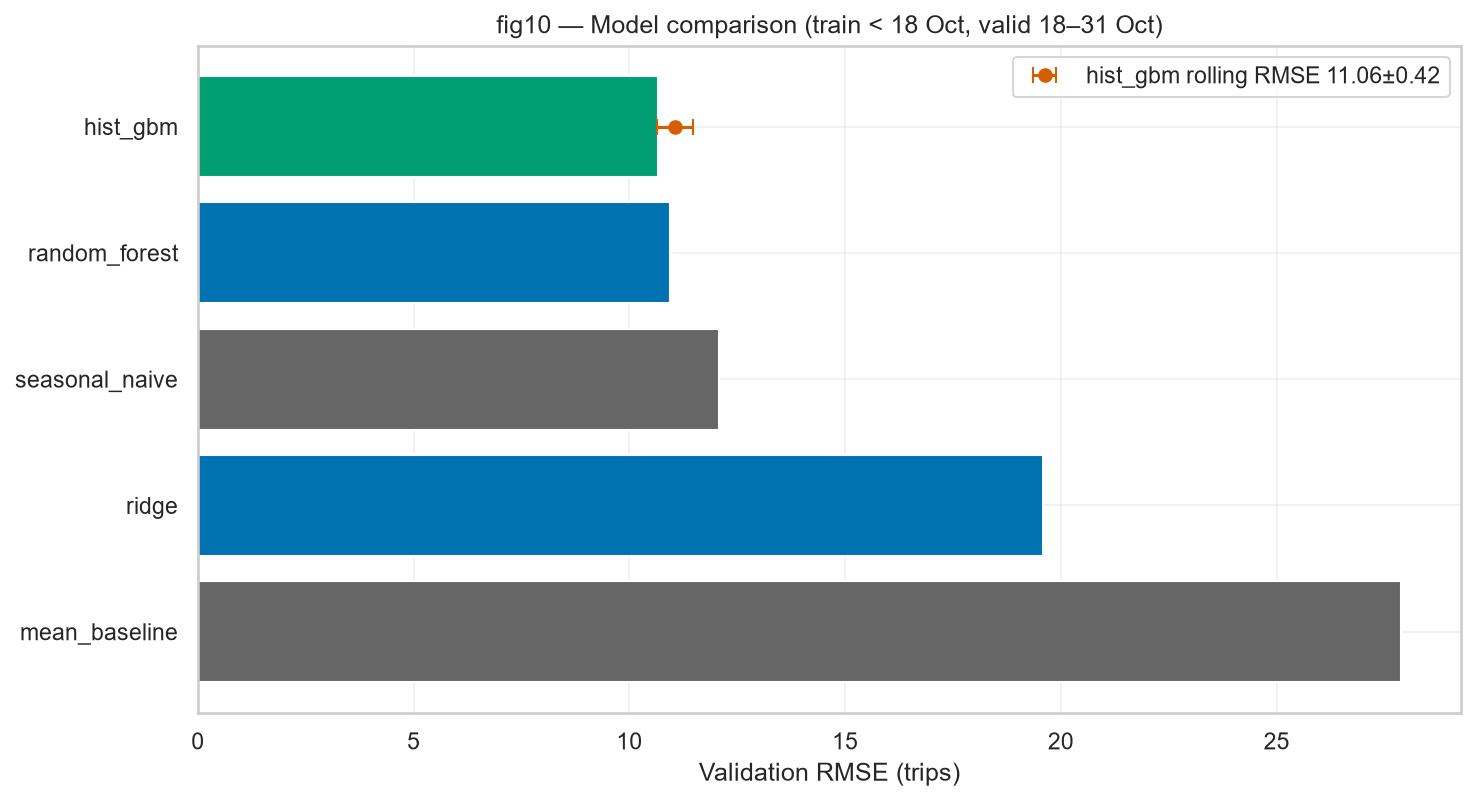

fig11_forecast_vs_actual.png


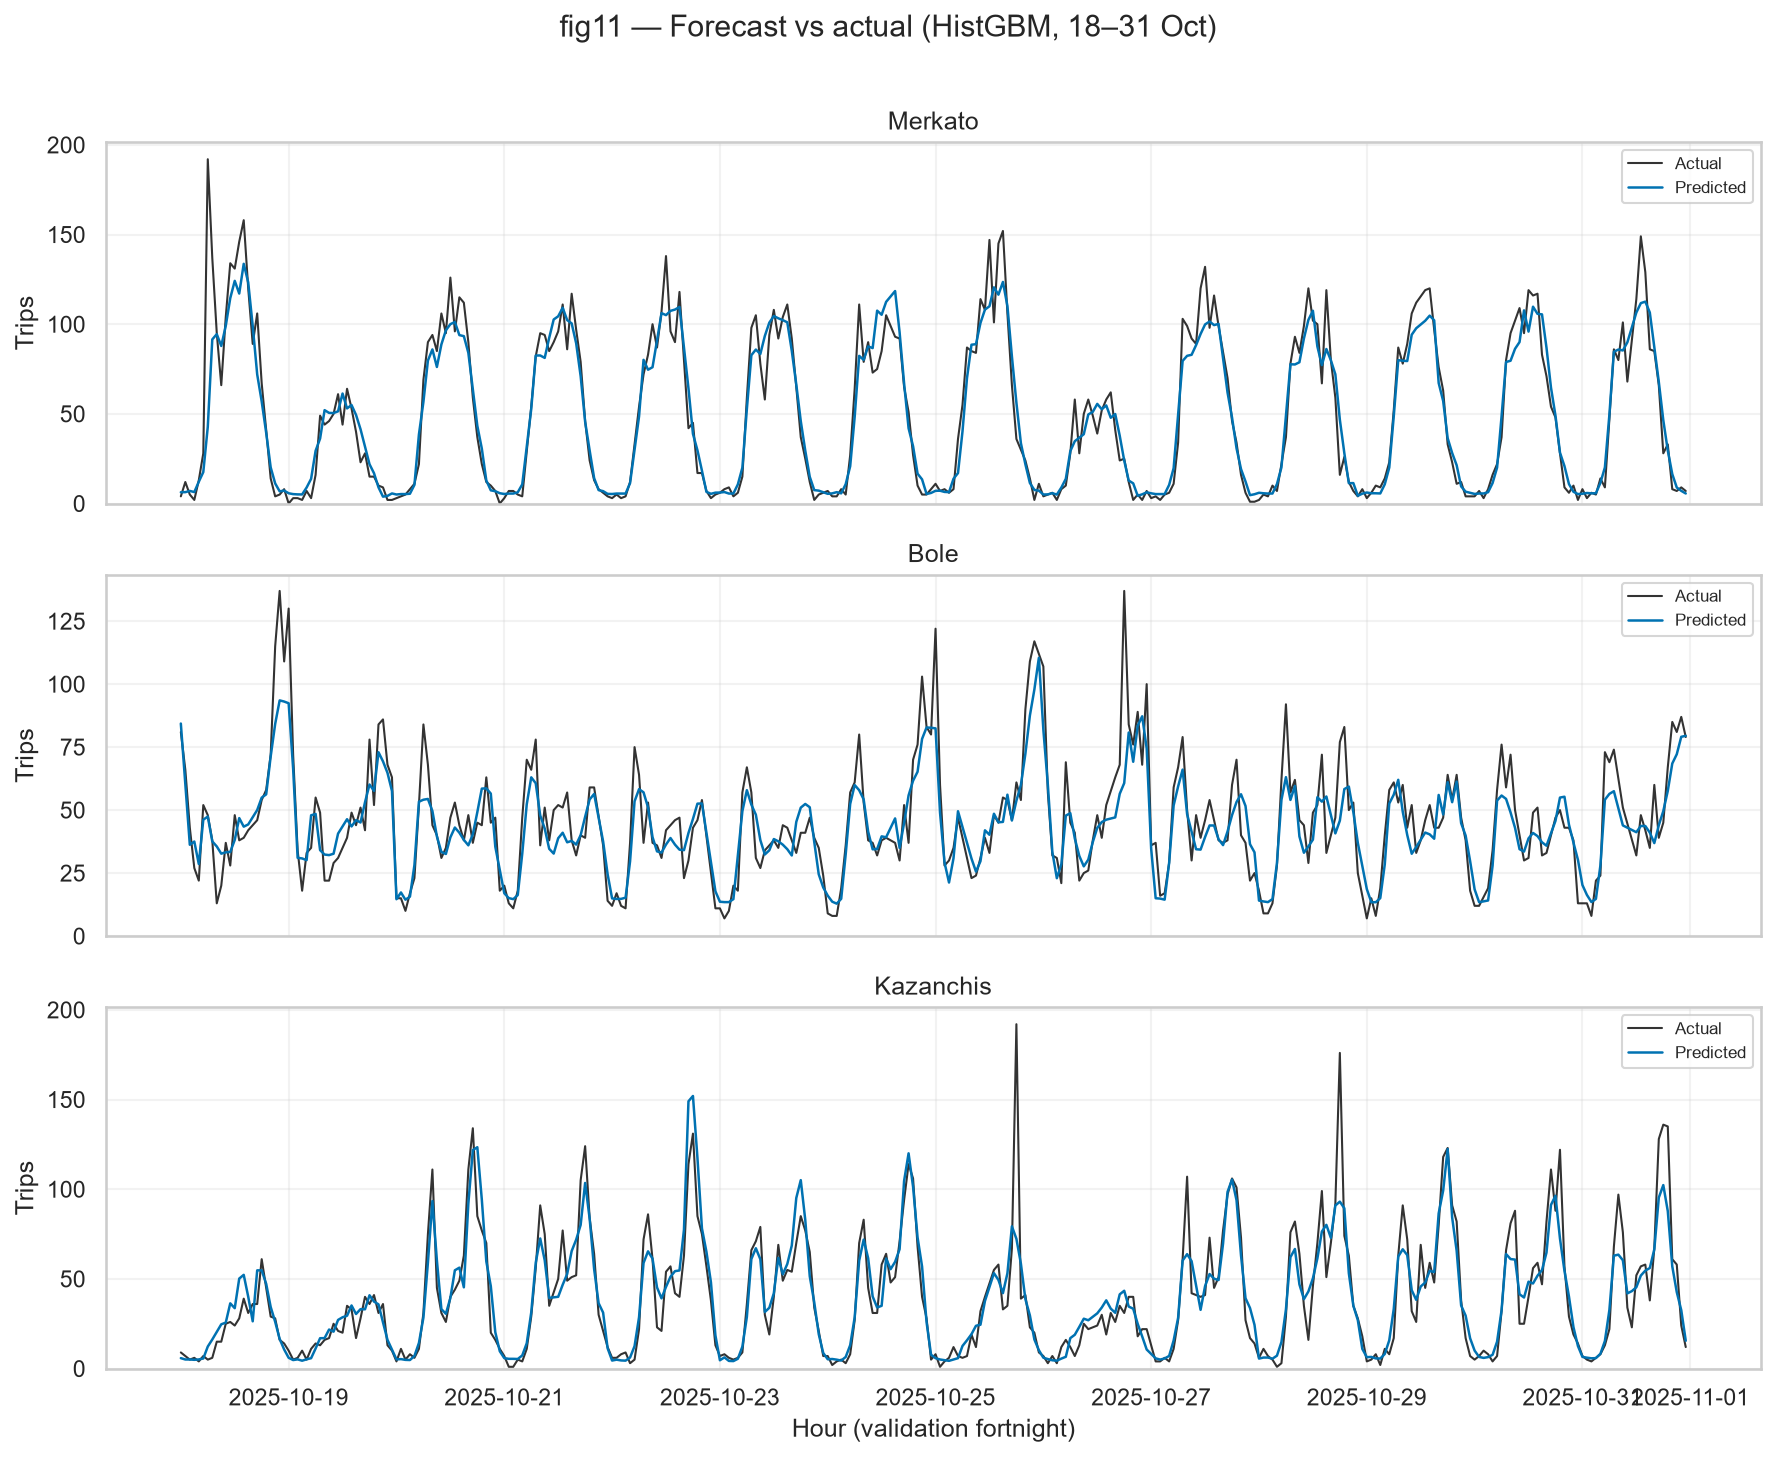

fig12_feature_importance.png


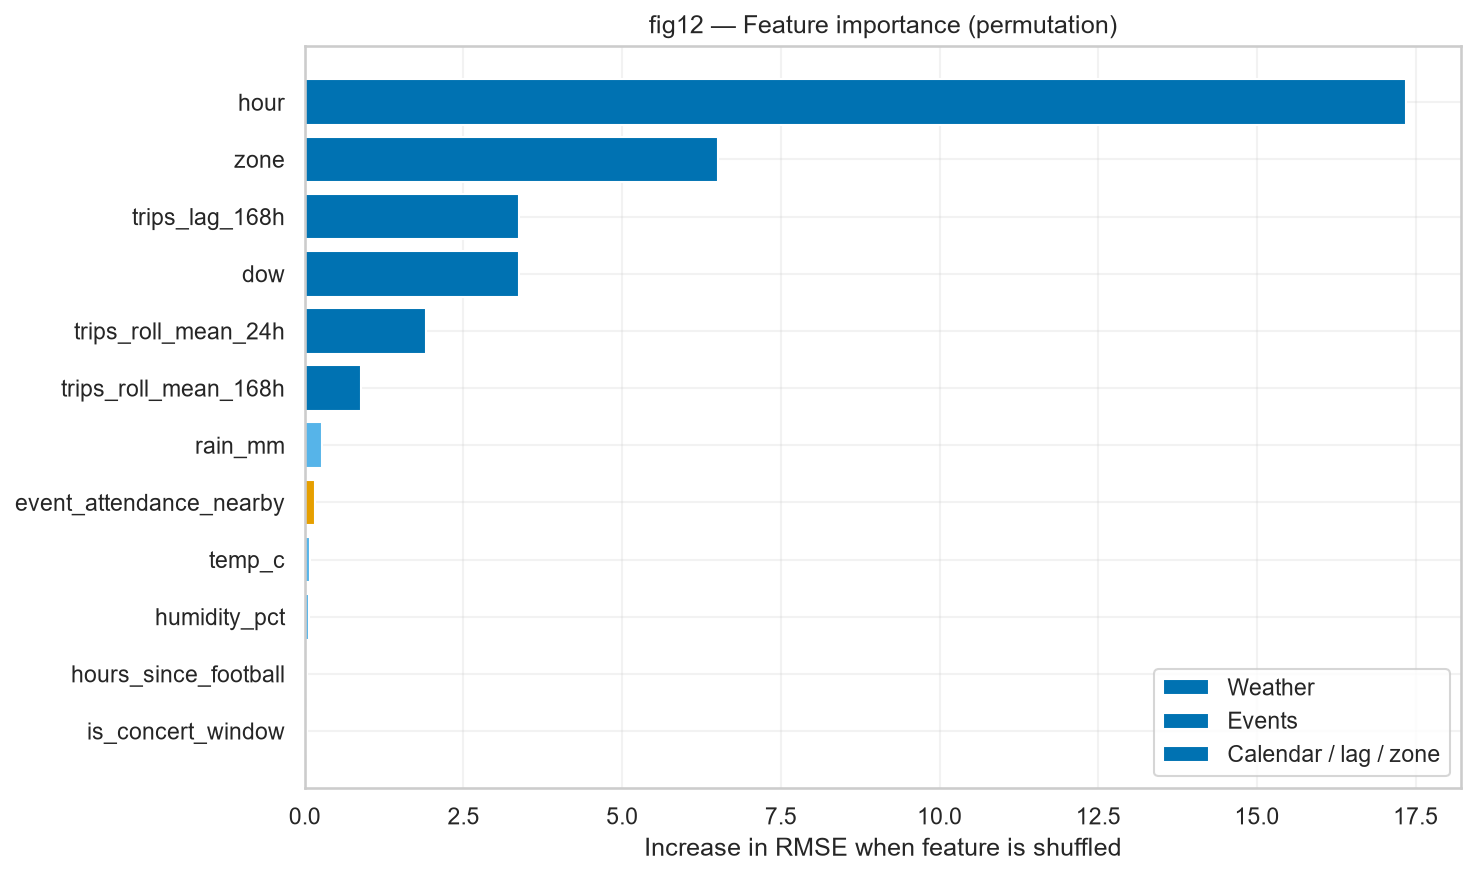

In [2]:
fig_dir = ROOT / 'figures'
captions = (fig_dir / 'figure_captions.md').read_text(encoding='utf-8')
display(Markdown(captions))

for p in sorted(fig_dir.glob('fig*.png')):
    print(p.name)
    display(Image(filename=str(p), width=900))